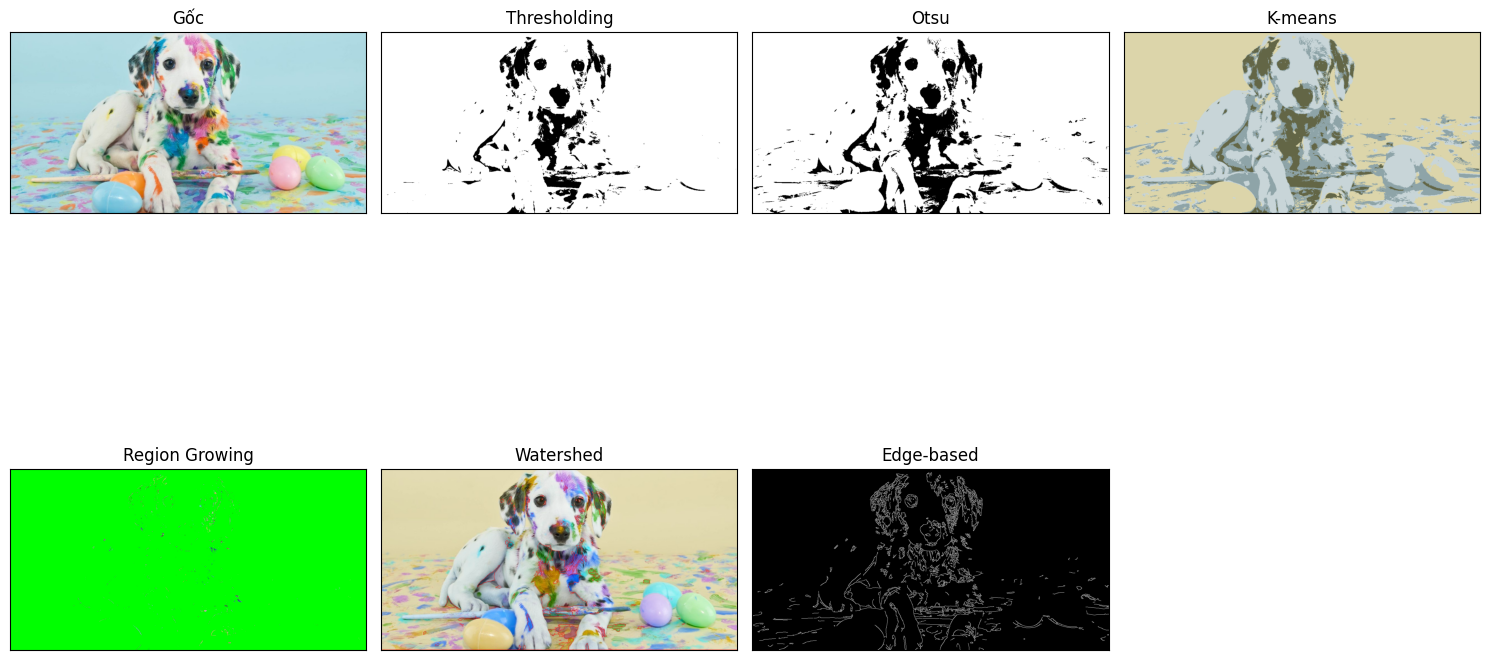

True

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as Duc

image = cv2.imread('dog.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, thresh1 = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

_, thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

z = image.reshape((-1, 3))
z = np.float32(z)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 4 
_, label, center = cv2.kmeans(z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
center = np.uint8(center)
res = center[label.flatten()]
kmeans_img = res.reshape((image_rgb.shape))

h, w = gray.shape
seed_point = (w // 2, h // 2)
mask = np.zeros((h + 2, w + 2), np.uint8)
region_growing = image.copy()
cv2.floodFill(region_growing, mask, seed_point, (0, 255, 0), (20, 20, 20), (20, 20, 20))

ret, markers = cv2.connectedComponents(thresh_otsu)
markers = markers + 1
markers[thresh_otsu == 0] = 0
watershed_img = image.copy()
markers = cv2.watershed(watershed_img, markers)
watershed_img[markers == -1] = [255, 0, 0]

edges = cv2.Canny(gray, 100, 200)

titles = ['Gốc', 'Thresholding', 'Otsu', 'K-means', 'Region Growing', 'Watershed', 'Edge-based']
images = [image_rgb, thresh1, thresh_otsu, kmeans_img, region_growing, watershed_img, edges]

Duc.figure(figsize=(15, 10))
for i in range(7):
    Duc.subplot(2, 4, i+1)
    Duc.imshow(images[i], 'gray' if i in [1, 2, 6] else None)
    Duc.title(titles[i])
    Duc.xticks([]), Duc.yticks([])

Duc.tight_layout()
Duc.show()


cv2.imwrite('1_threshold.jpg', thresh1)
cv2.imwrite('2_otsu.jpg', thresh_otsu)
cv2.imwrite('3_kmeans.jpg', cv2.cvtColor(kmeans_img, cv2.COLOR_RGB2BGR))
cv2.imwrite('6_edges.jpg', edges)